In [6]:
import pandas as pd
import numpy as np

In [7]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep = ";")
red["wine_type"] = 0
white["wine_type"] = 1

df = pd.concat([red, white], ignore_index=True)
#df = df.drop_duplicates()


<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020  

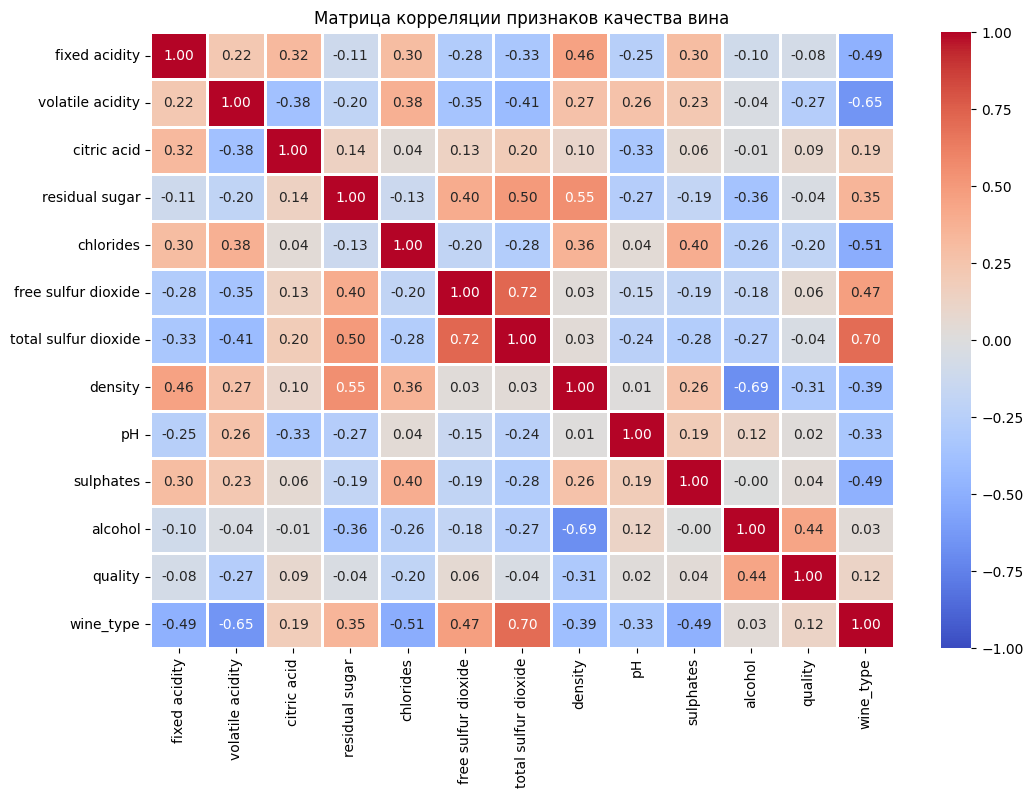

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.head)
print(df.describe())
print(df["quality"].value_counts().sort_index())
corr_matrix = df.select_dtypes(include='number').corr()

numeric_feautures = df.select_dtypes(include="number").columns
skewness = df[numeric_feautures].skew().sort_values(ascending=False)
skewed = skewness[abs(skewness) > 0.75].index.tolist()
print(f"Признаки со скошенностью более {0.75}")
print(skewed)

plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1.0)

plt.title("Матрица корреляции признаков качества вина")
plt.show()

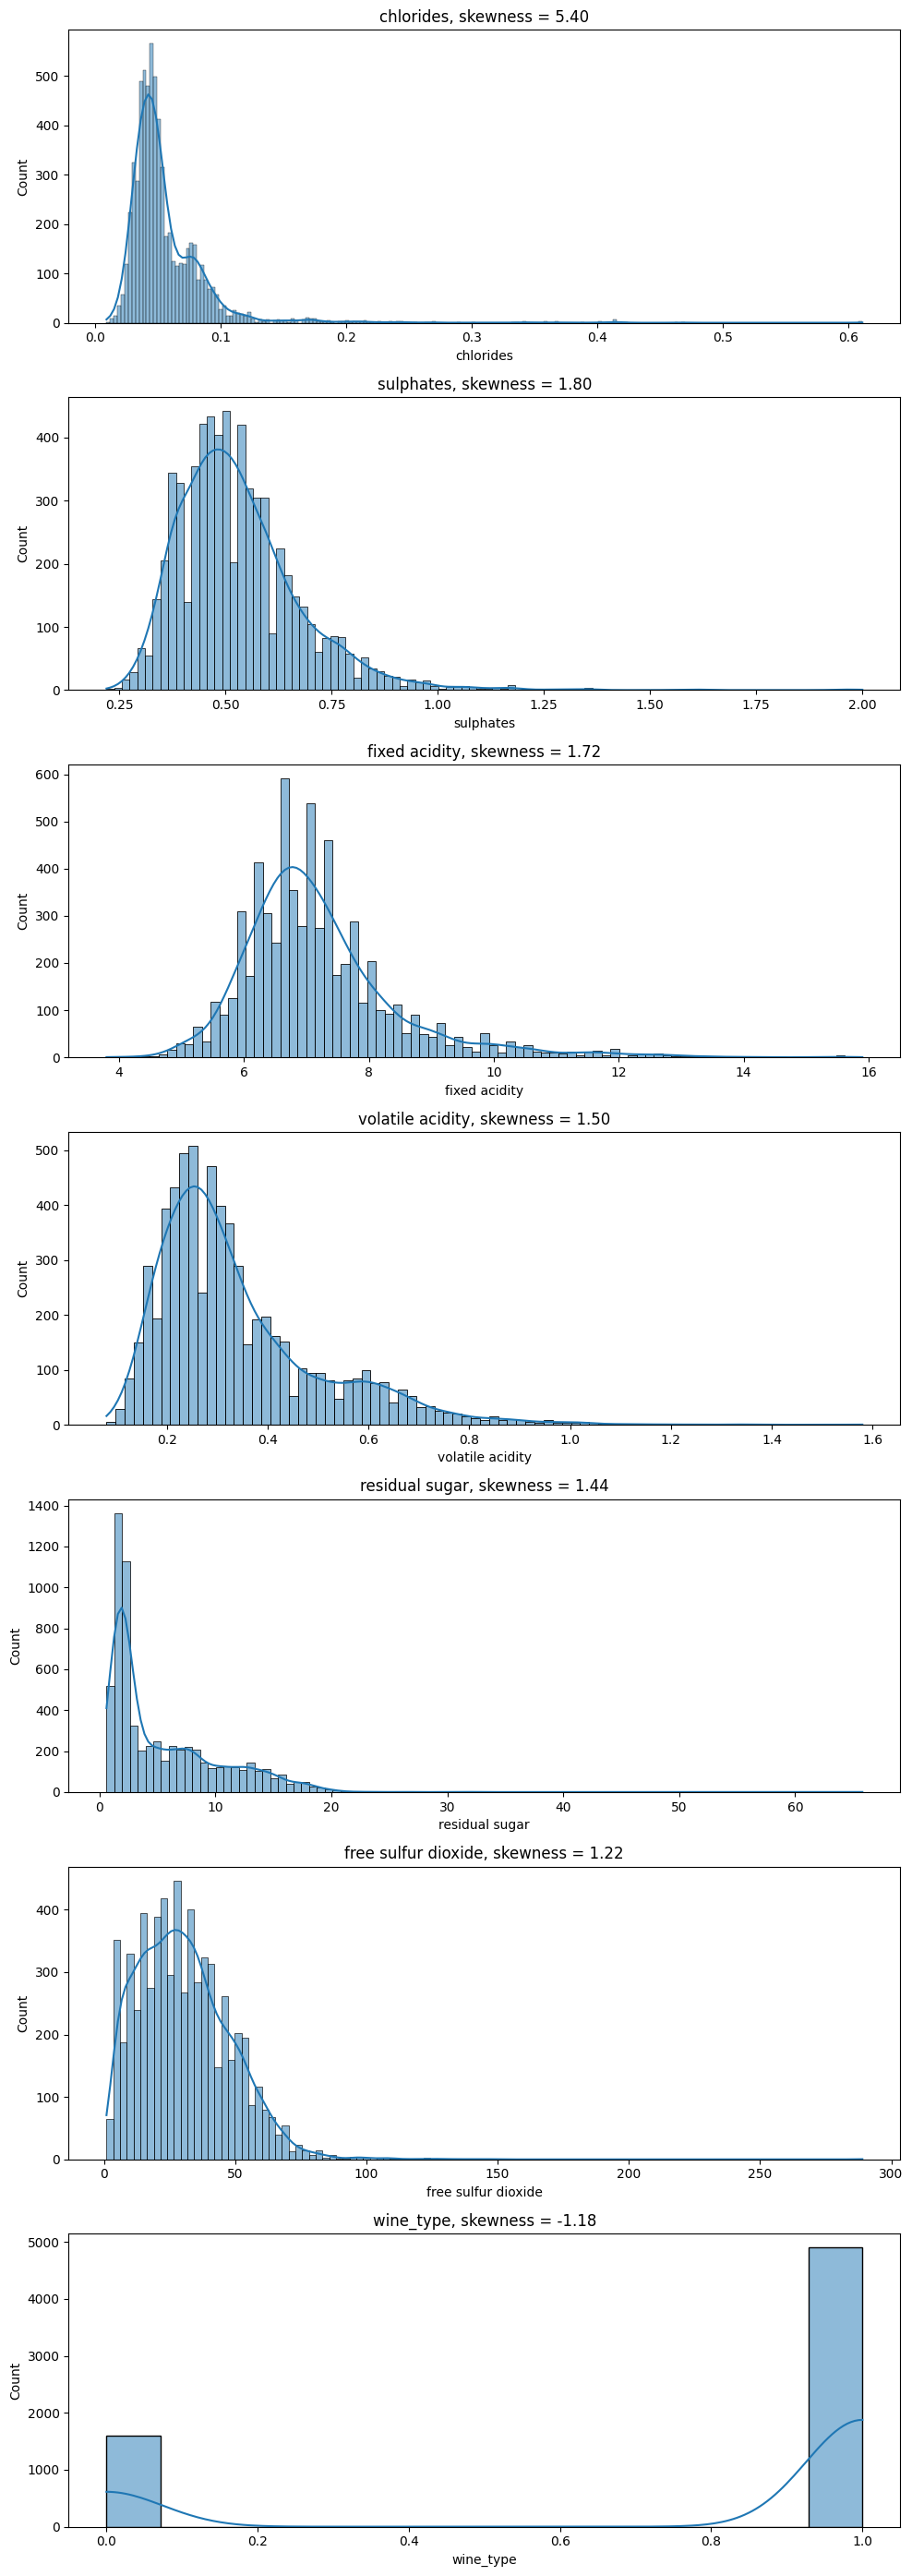

In [9]:
fig, axes = plt.subplots(len(skewed), 1, figsize=(10, 4 * len(skewed)))

for ax, feature in zip(axes, skewed):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(f"{feature}, skewness = {df[feature].skew():.2f}")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="quality")
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(5197, 12) (1300, 12)


In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

predicted_baseline = baseline.predict(X_test)


In [12]:
results = {}

def evaluate(name, y_true, y_predicted):
    results[name] = {
        "RMSE": root_mean_squared_error(y_true, y_predicted),
        "MAE": mean_absolute_error(y_true, y_predicted)
    }
    
    print(f"{name}: RMSE = {results[name]['RMSE']:.5f}, MAE = {results[name]['MAE']:.5f}")
    
evaluate("Baseline", y_test, predicted_baseline,)

Baseline: RMSE = 0.87377, MAE = 0.68609


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

def add_log(data):
    d = data.copy()
    d[skewed] = np.log1p(d[skewed])
    return d

X_train_log, X_test_log = add_log(X_train), add_log(X_test)
    

linear_model = make_pipeline(StandardScaler(), LinearRegression())

linear_model.fit(X_train_log, y_train)
linear_model_predicted = linear_model.predict(X_test_log)
evaluate("LinearRegression: ", y_test, linear_model_predicted)

LinearRegression: : RMSE = 0.71993, MAE = 0.56116


alcohol                 0.327
volatile acidity       -0.244
residual sugar          0.180
free sulfur dioxide     0.173
total sulfur dioxide   -0.165
density                -0.124
sulphates               0.101
wine_type              -0.073
fixed acidity           0.046
pH                      0.041
chlorides              -0.027
citric acid            -0.009
dtype: float64


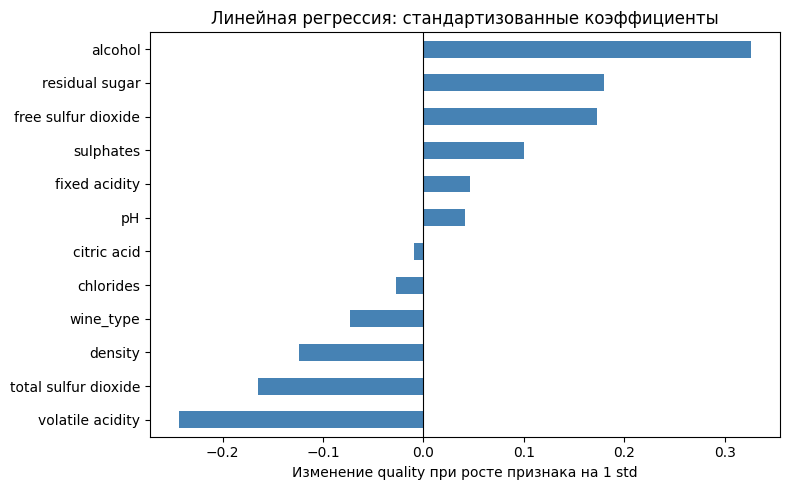

In [14]:
linear_coefs = pd.Series(
    linear_model[-1].coef_, index=X.columns
).sort_values(key=abs, ascending=False)

print(linear_coefs.round(3))

plt.figure(figsize=(8, 5))
linear_coefs.sort_values().plot.barh(color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Линейная регрессия: стандартизованные коэффициенты")
plt.xlabel("Изменение quality при росте признака на 1 std")
plt.tight_layout()
plt.show()

Стандратная гребневая регрессия. Как видно, она не показывает преимуществ по сравнению с линейной моделью без регуляризации. Значит необходимы дополнительные инструменты для прироста качества линейной модели

In [15]:
from sklearn.linear_model import Ridge   
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1),
)

ridge_model.fit(X_train_log, y_train)

ridge_model_pred = ridge_model.predict(X_test_log)
evaluate("Ridge", y_test, ridge_model_pred)

Ridge: RMSE = 0.71994, MAE = 0.56116


In [16]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer

elasticNet_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False, interaction_only=False),
    StandardScaler(),
    SplineTransformer(n_knots=5, degree=3),
    ElasticNetCV(
        l1_ratio=np.linspace(0.1, 1, 10),
        cv=5,
        random_state=42,
        n_jobs=-1,
        max_iter=100000
    )
)

elasticNet_model.fit(X_train_log, y_train)

elasticNet_model_pred = elasticNet_model.predict(X_test_log)

evaluate("ElasticNet", y_test, elasticNet_model_pred)

ElasticNet: RMSE = 0.68403, MAE = 0.53290


In [17]:
names = elasticNet_model[:-1].get_feature_names_out()
coefs = pd.Series(elasticNet_model[-1].coef_, index=names)

print(coefs.sort_values(key=abs, ascending=False).head(20).round(3))

density_sp_2                               -3.974
free sulfur dioxide^2_sp_5                 -3.538
volatile acidity alcohol_sp_1              -2.657
residual sugar^2_sp_3                       2.232
fixed acidity volatile acidity_sp_1         2.154
chlorides pH_sp_2                          -2.102
fixed acidity sulphates_sp_5                2.066
volatile acidity density_sp_1               1.966
total sulfur dioxide sulphates_sp_4        -1.768
pH alcohol_sp_0                             1.735
residual sugar pH_sp_4                     -1.705
volatile acidity wine_type_sp_1             1.588
residual sugar total sulfur dioxide_sp_5   -1.566
pH wine_type_sp_4                          -1.471
fixed acidity wine_type_sp_4                1.439
total sulfur dioxide sulphates_sp_1         1.429
density_sp_3                                1.350
fixed acidity chlorides_sp_2                1.335
fixed acidity volatile acidity_sp_4        -1.273
volatile acidity pH_sp_5                   -1.270


Гребневая регрессия с построением базисных сплайнов (по сути полиномов степени n)
в узлах регрессионной функции для сглаживания резких углов, точнее более четкого 
построения модели, используя нелинейные зависимости между признаками, но создавая
член регрессионной функции от которого линейно зависит искомая модель
$y_{i} = w_{0} + \sum_{i=1}^{K} w_{i}B_{i}(x_i)$, где $B_{i}$ - базис сплайн $i$-го признака; $K = degree + knots - 1$ (степень сплайнов + кол-во узлов - 1) - кол-во сплайнов
PolynomialFeatures также создает нелинейную зависимость, кроме того перемножая
признаки между собой, создавая более четкую картину для линейной модели
$y_{i} = w_{0} + \sum_{i=1}^{n} \sum_{j=1}^{m} w_{ij}x_{ij}$

In [18]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.preprocessing import SplineTransformer
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_modelCV = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    SplineTransformer(n_knots=5, degree=3),
    StandardScaler(),
    RidgeCV(alphas = np.logspace(-4, 4, 20), cv=cv)
)

ridge_modelCV.fit(X_train_log, y_train)
ridge_modelCV_predicted = ridge_modelCV.predict(X_test_log)

evaluate("RidgeCV", y_test, ridge_modelCV_predicted)

RidgeCV: RMSE = 0.69242, MAE = 0.53987


In [19]:
names = ridge_modelCV[:-1].get_feature_names_out()
coefs = pd.Series(ridge_modelCV[-1].coef_, index=names)

print(coefs.sort_values(key=abs, ascending=False).head(20).round(3))

free sulfur dioxide wine_type_sp_2         -0.055
pH alcohol_sp_0                             0.054
fixed acidity wine_type_sp_6               -0.052
volatile acidity alcohol_sp_0               0.051
residual sugar total sulfur dioxide_sp_4    0.040
pH alcohol_sp_2                            -0.038
fixed acidity alcohol_sp_0                 -0.036
free sulfur dioxide sulphates_sp_0         -0.034
density_sp_2                               -0.033
density^2_sp_2                             -0.032
fixed acidity free sulfur dioxide_sp_6     -0.032
fixed acidity free sulfur dioxide_sp_1     -0.031
volatile acidity alcohol_sp_2              -0.030
total sulfur dioxide sulphates_sp_4        -0.028
density^2_sp_0                              0.028
density_sp_0                                0.028
volatile acidity alcohol_sp_3               0.026
fixed acidity residual sugar_sp_4           0.025
density_sp_1                                0.024
residual sugar alcohol_sp_2                -0.024


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=50,
    min_samples_leaf=2,
    max_features=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

predicted_rf = rf_model.predict(X_test)

evaluate("Random Forest", y_test, predicted_rf)

Random Forest: RMSE = 0.60115, MAE = 0.44004


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=190,
    learning_rate=2e-2,
    max_depth=14,
    subsample=0.38,
    random_state=50
)

gb_model.fit(X_train, y_train)

predicted_gb = gb_model.predict(X_test)

evaluate("Gradient Boosting", y_test, predicted_gb)

Gradient Boosting: RMSE = 0.59553, MAE = 0.43548


,RMSE,MAE
Baseline,0.8738,0.6861
LinearRegression:,0.7199,0.5612
Ridge,0.7199,0.5612
ElasticNet,0.6840,0.5329
RidgeCV,0.6924,0.5399
Random Forest,0.6012,0.4400
Gradient Boosting,0.5955,0.4355


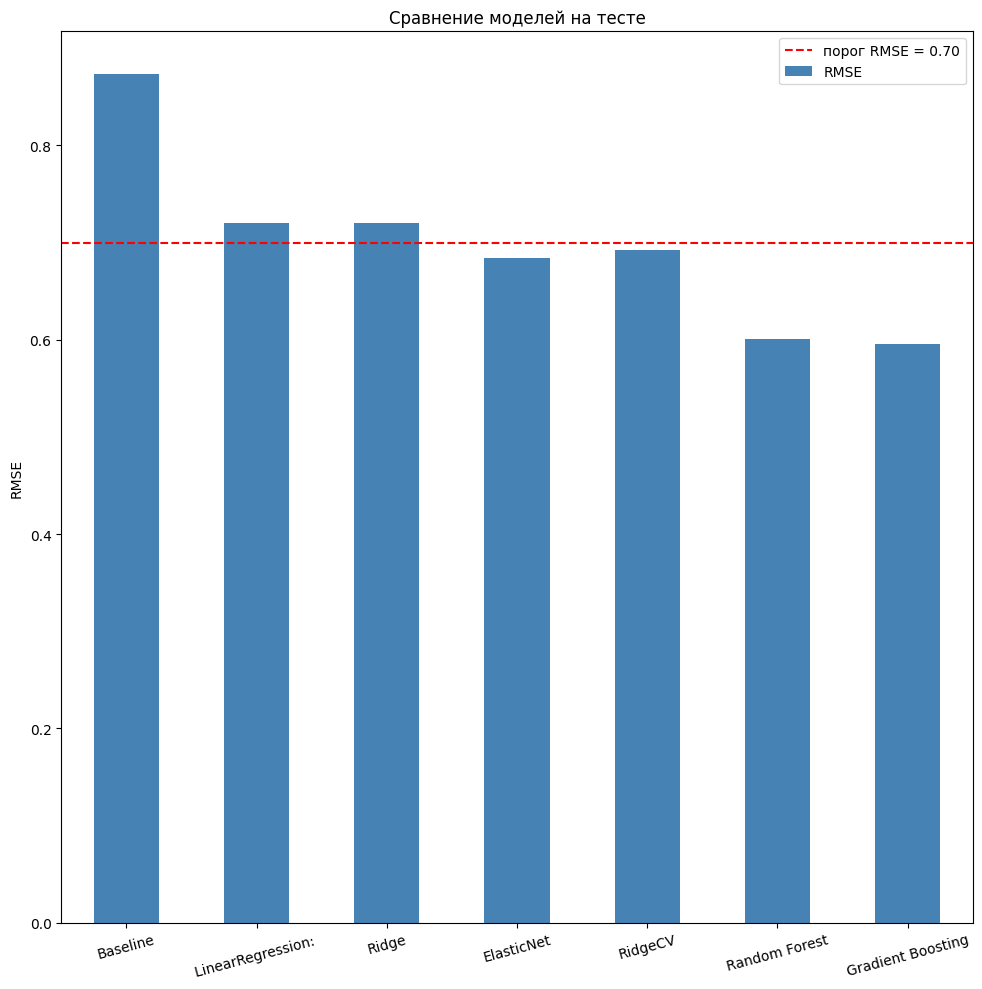

Превзошли baseline: ['LinearRegression: ', 'Ridge', 'ElasticNet', 'RidgeCV', 'Random Forest', 'Gradient Boosting']
Превзошли порог качества: ['ElasticNet', 'RidgeCV', 'Random Forest', 'Gradient Boosting']


In [22]:
results_table = pd.DataFrame(results).T.round(4)
display(results_table)

results_table["RMSE"].plot.bar(figsize=(10, 10), color="steelblue", rot=15)
plt.axhline(0.70, color="red", linestyle="--", label="порог RMSE = 0.70")
plt.ylabel("RMSE")
plt.title("Сравнение моделей на тесте")
plt.legend()
plt.tight_layout()
plt.show()

beat_baseline = results_table.index[results_table["RMSE"] < results_table.loc["Baseline", "RMSE"]]
beat_quality = results_table.index[results_table["RMSE"] < 0.7]
print("Превзошли baseline:", list(beat_baseline))
print("Превзошли порог качества:", list(beat_quality))

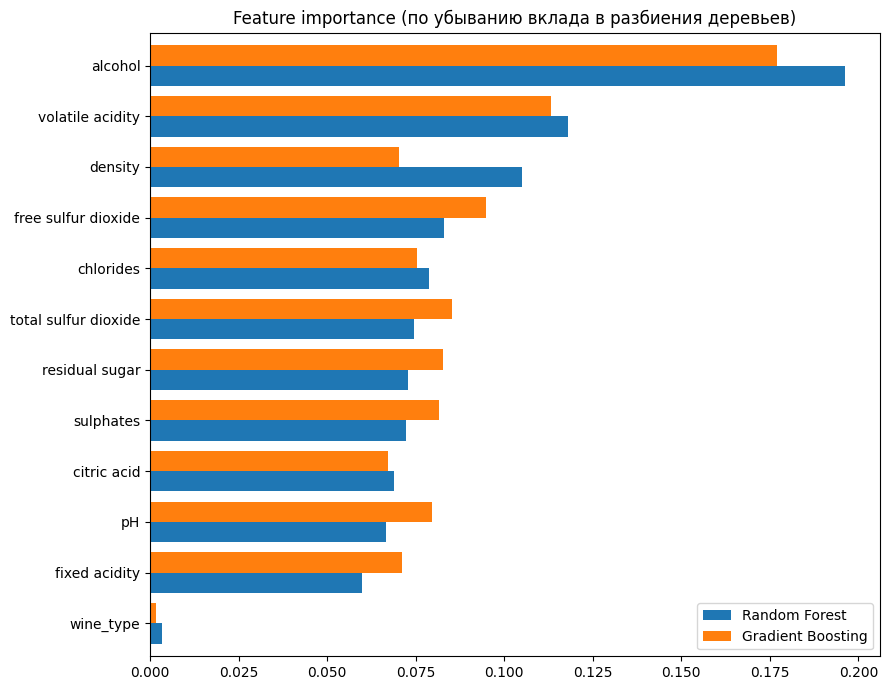

In [23]:
importance = pd.DataFrame(
    {
        "Random Forest": rf_model.feature_importances_,
        "Gradient Boosting": gb_model.feature_importances_,
    },
    index=X.columns,
).sort_values("Random Forest")

importance.plot.barh(figsize=(9, 7), width=0.8)
plt.title("Feature importance (по убыванию вклада в разбиения деревьев)")
plt.tight_layout()
plt.show()